# Exploratory Data Analysis — MedEmbed Training Triplet Dataset

**AAI-590 Capstone — Domain-Adapted Embeddings and Reranking in Enterprise Medical RAG**

This notebook explores the [MedEmbed training triplet dataset](https://huggingface.co/datasets/abhinand/MedEmbed-training-triplets-v1)
(Balachandran, 2024), the dataset used to fine-tune both the bi-encoder retriever and the
cross-encoder reranker for this project. The dataset is built from real PubMed Central clinical
notes, discharge summaries, and case reports, with query and relevance labels generated by
prompting LLaMA 3.1 70B over the source text rather than by human annotators.

This notebook only **measures and reports** on the raw dataset. It does not filter, clean, or
split the data — that logic belongs to the data-cleaning pipeline built in a later notebook,
once the diagnostics below have established which issues are worth handling and how severe
each one is.

**What this notebook covers:**
1. Load the dataset and report headline counts
2. Query and passage length distributions
3. Anaphoric / context-dependent query rate
4. False-negative reuse (generic passages reused as negatives across unrelated queries)
5. Degenerate positives (near-contentless passages)
6. Query type breakdown (keyword-style vs. natural-question style)
7. Lexical overlap between queries and their positive passages


In [1]:
import re
import string
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset

FIGURES_DIR = "../figures"
plt.rcParams["figure.dpi"] = 110


## 1. Load the dataset

The Hugging Face dataset ships three configurations: `merged` and `queries` are per-query views
(one row per query, with all its negatives), and `corpus` is the deduplicated passage store. We
use `merged` for the query/positive/negative-level analysis and `corpus` for the passage-level
analysis (length distribution, degenerate-positive check).


In [2]:
merged = load_dataset("abhinand/MedEmbed-training-triplets-v1", "merged")["train"]
corpus = load_dataset("abhinand/MedEmbed-training-triplets-v1", "corpus")["train"]

df = merged.to_pandas()
corpus_df = corpus.to_pandas()

print(f"Unique queries: {len(df)}")
print(f"Unique corpus passages: {len(corpus_df)}")
print(f"Total triplet rows: {sum(len(n) for n in df['neg'])}")
print(f"Mean negatives per query: {np.mean([len(n) for n in df['neg']]):.2f}")


Unique queries: 21689
Unique corpus passages: 27590
Total triplet rows: 232684
Mean negatives per query: 10.73


## 2. Query and passage length distributions

Understanding the length range of queries and passages matters for a very concrete modeling
decision: the maximum sequence length used when fine-tuning the bi-encoder. If passages are
short, a large `max_seq_length` wastes GPU memory that could instead go toward a larger
contrastive training batch.


Query length: min=10, max=131, mean=45.1, median=44
Passage length: min=5, max=993, mean=171.3, median=154


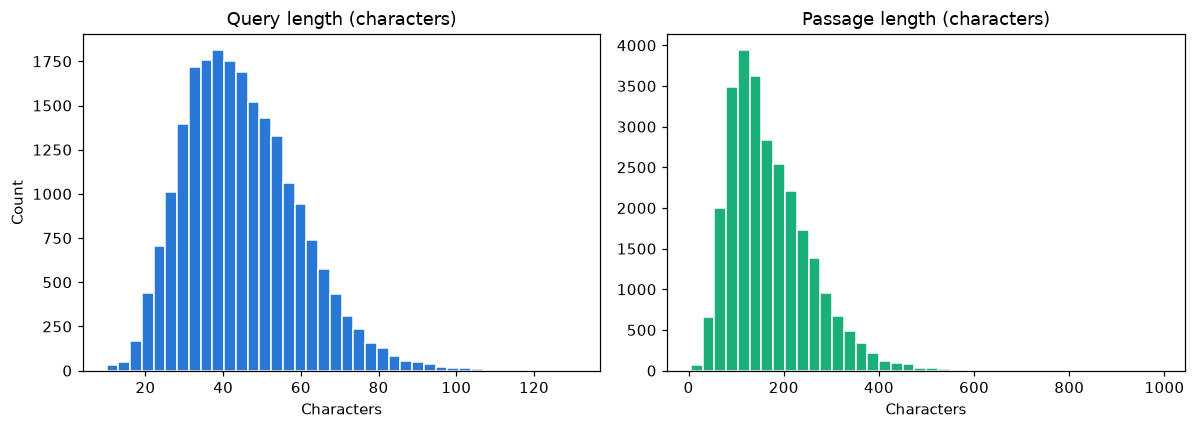

In [3]:
query_lengths = df["query"].str.strip().str.len()
passage_lengths = corpus_df["text"].str.len()

print(f"Query length: min={query_lengths.min()}, max={query_lengths.max()}, "
      f"mean={query_lengths.mean():.1f}, median={query_lengths.median():.0f}")
print(f"Passage length: min={passage_lengths.min()}, max={passage_lengths.max()}, "
      f"mean={passage_lengths.mean():.1f}, median={passage_lengths.median():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(query_lengths, bins=40, color="#2a78d6", edgecolor="white")
axes[0].set_title("Query length (characters)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")

axes[1].hist(passage_lengths, bins=40, color="#1baf7a", edgecolor="white")
axes[1].set_title("Passage length (characters)")
axes[1].set_xlabel("Characters")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig1_length_distributions.png", dpi=150)
plt.show()


**Takeaway:** queries cluster tightly between 30 and 60 characters (short keyword phrases or
single-sentence questions). Passages show a longer right tail but are still bounded well under
1,000 characters. This supports using a modest `max_seq_length` (e.g. 320 tokens) for bi-encoder
fine-tuning rather than the model's full 8192-token capacity — that capacity would be wasted
memory here, better spent on batch size.


## 3. Anaphoric / context-dependent query rate

A meaningful share of queries are unanswerable in isolation — questions like *"What was the
outcome of the patient's treatment?"* that could correctly describe hundreds of different
passages, meaning there is no unique gold answer. These are noise during training (they teach
the model an arbitrary query→passage association) and invalid as evaluation items (there is no
single correct passage to rank first).

The heuristic below is a **lightweight lexical proxy**, not the validated production filter. It
flags a query as anaphoric when it references "the patient" generically together with a
generic-outcome word, but contains no specific clinical entity term. The production version of
this filter will instead match against a UMLS or MeSH term list (or a clinical NER pass), and
will be validated by hand-labeling a sample of flagged queries and reporting precision/recall —
that validation step happens in the data-cleaning notebook, not here.


In [4]:
PATIENT_REF = re.compile(r"\bthe patient'?s?\b|\bhis\b|\bher\b", re.IGNORECASE)
GENERIC_OUTCOME_WORDS = re.compile(
    r"\boutcome\b|\bcondition\b|\bfare\b|\bresult\b|\bafter\b|\bfollowing\b",
    re.IGNORECASE,
)
# Small seed list of clinical-entity term fragments. The production filter will use a full
# UMLS/MeSH term list or a clinical NER pass instead of this hand-written seed list.
CLINICAL_ENTITY_SEED = re.compile(
    r"\b(mg|ml|therapy|syndrome|scale|score|surgery|diagnosis|treatment|"
    r"disease|infection|tumor|cancer|fracture|artery|vein|nerve|biopsy|"
    r"lesion|carcinoma|virus|bacteria|antibiotic|chemotherapy|radiotherapy)\b",
    re.IGNORECASE,
)


def is_anaphoric(query: str) -> bool:
    has_patient_ref = bool(PATIENT_REF.search(query))
    has_generic_outcome = bool(GENERIC_OUTCOME_WORDS.search(query))
    has_entity = bool(CLINICAL_ENTITY_SEED.search(query))
    return has_patient_ref and has_generic_outcome and not has_entity


df["is_anaphoric"] = df["query"].apply(is_anaphoric)
anaphoric_rate = df["is_anaphoric"].mean()
print(f"Anaphoric query rate (heuristic filter): {anaphoric_rate:.1%} "
      f"({df['is_anaphoric'].sum()} of {len(df)})")

print("\nExample flagged queries:")
for q in df[df["is_anaphoric"]]["query"].head(5):
    print(f"  - {q.strip()}")


Anaphoric query rate (heuristic filter): 3.3% (718 of 21689)

Example flagged queries:
  - Can the patient perform strenuous activities after discharge?
  - Can the patient's condition be caused by smoking?
  - Can the patient's condition be detected by heart MRI?
  - Can the patient's condition be managed with medication?
  - Can the patient's condition be managed without medication?


**Takeaway:** roughly 3.3% of queries are flagged by this heuristic. That's a meaningful but
manageable slice of the training data to remove. The next step in the actual cleaning pipeline
is to validate this rate against a hand-labeled sample before committing to it as the final
filter.


## 4. False-negative reuse

Because negatives were mined automatically rather than hand-curated, some generic passages
(e.g. boilerplate follow-up instructions) get attached as a "negative" to hundreds of unrelated
queries — even when that passage would actually be a reasonable answer to some of them. A
negative reused across many queries is a signal of generic filler rather than a genuine hard
negative, and is a candidate for removal before training.


Negative reuse: mean=10.69, median=6, max=447
Negatives reused by >= 20 distinct queries: 2865 of 21764 unique negatives


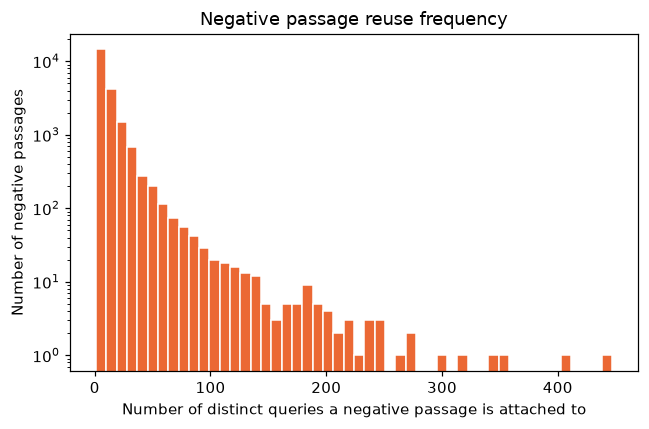


Most frequently reused negative passages:
  (447x) The patient received prompt surgical treatment, followed by appropriate postoperative care. The pati
  (407x) The patient was treated for his symptoms while in the hospital.
  (349x) Recommend to follow-up with the surgeon for a postoperative visit.
  (341x) PLAN: Follow-up with the patient as clinically indicated.
  (318x) The patient was admitted to our hospital with complaints of epigastric discomfort.


In [5]:
neg_id_counter = Counter()
for neg_ids in df["neg_id"]:
    neg_id_counter.update(neg_ids)

reuse_counts = pd.Series(neg_id_counter.values())
print(f"Negative reuse: mean={reuse_counts.mean():.2f}, "
      f"median={reuse_counts.median():.0f}, max={reuse_counts.max()}")
print(f"Negatives reused by >= 20 distinct queries: "
      f"{(reuse_counts >= 20).sum()} of {len(reuse_counts)} unique negatives")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(reuse_counts, bins=50, color="#eb6834", edgecolor="white")
ax.set_title("Negative passage reuse frequency")
ax.set_xlabel("Number of distinct queries a negative passage is attached to")
ax.set_ylabel("Number of negative passages")
ax.set_yscale("log")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig2_negative_reuse.png", dpi=150)
plt.show()

id_to_text = dict(zip(corpus_df["id"], corpus_df["text"]))
print("\nMost frequently reused negative passages:")
for nid, count in neg_id_counter.most_common(5):
    print(f"  ({count}x) {id_to_text.get(nid, '?')[:100]}")


**Takeaway:** the most-reused negative passage is attached to 447 different queries, and about
13% of unique negatives are reused by 20+ queries — a clear long tail of generic filler
passages, as the printed examples confirm (boilerplate discharge/follow-up language). The
cleaning pipeline will score these high-reuse (query, negative) pairs with the stock bge-m3
embedding model and drop pairs above a similarity threshold, rather than removing every reused
negative outright.


## 5. Degenerate positives

Some positive passages are so short they carry almost no clinical content (e.g. *"Surgery was
suggested."*). These weakly support contrastive learning since there's little semantic signal
to align the query against, so we flag passages below a minimum token count.


In [6]:
corpus_df["token_count"] = corpus_df["text"].str.split().str.len()
degenerate_threshold = 6
degenerate = corpus_df[corpus_df["token_count"] < degenerate_threshold]

print(f"Degenerate positives (< {degenerate_threshold} tokens): "
      f"{len(degenerate)} of {len(corpus_df)} passages "
      f"({len(degenerate) / len(corpus_df):.1%})")
print("\nExamples:")
for t in degenerate["text"].head(5):
    print(f"  - {t}")


Degenerate positives (< 6 tokens): 243 of 27590 passages (0.9%)

Examples:
  - ASPECTS score was 7.
  - Sudden onset severe anal pain.
  - Surgery was suggested.
  - The Burn Index was 32.75.
  - CAPTEM was tolerated well.


**Takeaway:** only about 0.9% of passages fall below the six-token threshold — a small, easily
removable slice of the corpus. This is a minor issue compared to false-negative reuse.


## 6. Query type breakdown: keyword-style vs. natural-question style

Understanding how queries are phrased matters for evaluation realism: if the dataset were
entirely natural-language questions, a model that only learns question-style phrasing would
still perform well, but real clinical search behavior includes many short keyword queries too.


Natural-question-style queries: 25.0%
Keyword-style queries: 75.0%


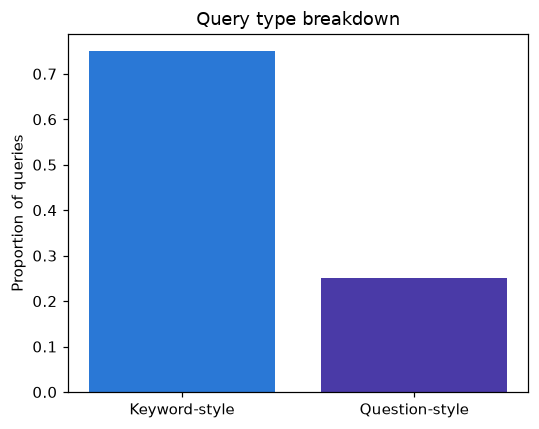

In [7]:
QUESTION_WORDS = re.compile(
    r"^\s*(what|how|why|when|where|which|who|does|is|are|can|was|were)\b",
    re.IGNORECASE,
)
df["is_question_style"] = df["query"].str.strip().apply(
    lambda q: bool(QUESTION_WORDS.match(q)) or q.strip().endswith("?")
)
question_rate = df["is_question_style"].mean()
print(f"Natural-question-style queries: {question_rate:.1%}")
print(f"Keyword-style queries: {1 - question_rate:.1%}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(
    ["Keyword-style", "Question-style"],
    [1 - question_rate, question_rate],
    color=["#2a78d6", "#4a3aa7"],
)
ax.set_ylabel("Proportion of queries")
ax.set_title("Query type breakdown")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig3_query_type.png", dpi=150)
plt.show()


**Takeaway:** 75% of queries are keyword-style rather than full natural-language questions. This
matches realistic clinical search behavior and confirms the evaluation set will meaningfully
test short-query retrieval, not just question-answering-style matching.


## 7. Lexical overlap between query and positive passage

This is the most important diagnostic for justifying the model comparison in this project: how
much of the retrieval task is solvable by exact word matching (a lexical retriever like BM25)
versus how much requires semantic generalization (what a fine-tuned embedding model should
provide)? We measure this with Jaccard overlap between the non-stopword vocabulary of each query
and its positive passage.


Query-positive lexical (Jaccard) overlap: mean=0.090, median=0.062
Queries with zero lexical overlap with their positive passage: 33.9%


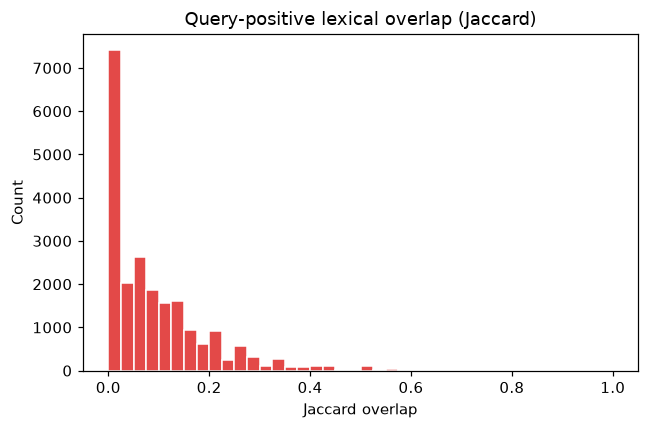

In [8]:
STOPWORDS = {
    "the", "a", "an", "of", "in", "on", "for", "and", "or", "to", "is",
    "was", "were", "with", "at", "by", "from", "that", "this", "what",
    "how", "did", "does", "patient", "patients",
}


def tokenize(text: str) -> set:
    text = text.lower().translate(str.maketrans("", "", string.punctuation))
    return {w for w in text.split() if w not in STOPWORDS and len(w) > 2}


def jaccard_overlap(query: str, passage: str) -> float:
    q_tokens = tokenize(query)
    p_tokens = tokenize(passage)
    if not q_tokens or not p_tokens:
        return 0.0
    return len(q_tokens & p_tokens) / len(q_tokens | p_tokens)


df["lexical_overlap"] = df.apply(
    lambda row: jaccard_overlap(row["query"], row["pos"]), axis=1
)
print(f"Query-positive lexical (Jaccard) overlap: "
      f"mean={df['lexical_overlap'].mean():.3f}, "
      f"median={df['lexical_overlap'].median():.3f}")
print(f"Queries with zero lexical overlap with their positive passage: "
      f"{(df['lexical_overlap'] == 0).mean():.1%}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["lexical_overlap"], bins=40, color="#e34948", edgecolor="white")
ax.set_title("Query-positive lexical overlap (Jaccard)")
ax.set_xlabel("Jaccard overlap")
ax.set_ylabel("Count")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig4_lexical_overlap.png", dpi=150)
plt.show()


**Takeaway:** mean Jaccard overlap is only 0.090, and 33.9% of queries share *zero* non-stopword
vocabulary with their positive passage at all. This is strong evidence that this dataset is
exactly the setting where a lexical retriever (BM25) should struggle and where a semantically
fine-tuned embedding model should show its clearest advantage — which is why BM25 is included as
a lexical reference point in the evaluation table rather than omitted as a "too weak to bother
with" baseline.

## Summary of findings

| Diagnostic | Result | Planned handling |
|---|---|---|
| Anaphoric queries | 3.3% (718 / 21,689) | Remove from train + eval, after validating filter against hand-labeled sample |
| False-negative reuse | up to 447 queries share one negative; ~13% of negatives reused 20+ times | Score with stock bge-m3, drop high-similarity pairs |
| Degenerate positives | 0.9% (243 / 27,590) | Remove passages below 6-token threshold |
| Query style | 75% keyword, 25% question | No action — informs realistic evaluation expectations |
| Lexical overlap | mean 0.090; 33.9% zero-overlap | Motivates BM25 as a lexical reference baseline |

These findings carry directly into the next steps of the project: the data-cleaning notebook
will implement and validate the anaphoric-query filter, drop high-similarity false-negative
pairs, remove degenerate positives, and perform the corpus-level 80/10/10 train/val/test split
described in the project's methodology.
